In [19]:
from astropy.io import ascii, fits
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import seaborn as sns
from spectral_cube import SpectralCube
import astropy.units as u
from matplotlib.ticker import ScalarFormatter

In [20]:
nu11 = 23.6944955e9
size_scale_factor = 1.5406
linewidth_scale_factor = 2.5503
Cube = SpectralCube.read('/home/scratch/hfwest/Pilot/Data/Pilot_NH3_11_cropped.fits').with_spectral_unit(u.km/u.s, velocity_convention = 'radio')
hdr = Cube.header
x_pixel_width = abs(hdr['CDELT1']) # Pixel size in degrees (pixel width of x axis, longitude)
v_channel_width = abs(hdr['CDELT3']) # Channel width (km/s) (channel width of v axis, velocity)

def expFunc(x, a, b):
    return a * np.power(x, b)

def ratios_to_radius(Volume: float, a: float, b: float, c: float):
    R1 = b/a
    R2 = c/a
    arg = (3 * Volume) / (4 * np.pi * R1 * R2)
    return pow(arg, 1/3) # returns pixel radius in 'a' dimension

In [21]:
print(v_channel_width)

0.7238786093363


In [26]:
# hdul = fits.open("/home/scratch/hfwest/Pilot/Results_ClumpFind/Pilot_08_cat.FIT")
params = '10 contour increments from 10$\sigma$ baseline'
hdul = fits.open("/home/scratch/lmorgan/Projects/GalacticBar/Midpoint_PaperII/SourceFinding/ClumpFind/Results/Pilot_NH3_11_10lev_10sig_cat.FIT")
pilot_table = Table(hdul[1].data)
pilot_table['Linear Size (pc)'] = np.zeros(len(pilot_table))
pilot_table['sigma (km/s)'] = np.zeros(len(pilot_table))
for row in pilot_table:
    row['Linear Size (pc)'] = ratios_to_radius(row['Volume'], max(row['Size1'], row['Size2']), min(row['Size1'], row['Size2']), row['Size3']) * 2 * x_pixel_width * (np.pi/180) * 7000 * size_scale_factor # Assumed distance to midpoint cloud: 7 kpc --> now in pc
    row['sigma (km/s)'] = row['Size3'] * v_channel_width * linewidth_scale_factor / (2 * np.sqrt(2 * np.log(2)))
pilot_table

PIDENT,Peak1,Peak2,Peak3,Cen1,Cen2,Cen3,Size1,Size2,Size3,Sum,Peak,Volume,Linear Size (pc),sigma (km/s)
int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,69.5,65.5,167.5,68.49962639653991,64.23166074856194,169.31568969625525,4.110160059635047,4.368929389433025,3.263100018284162,812.5898150347481,1.0573979518327228,2845.0,9.305081249366948,2.558171616031857
2,164.5,46.5,193.5,165.64148184478998,46.86369198391914,195.9198199848117,3.6128624976583383,3.2257689669180167,4.899861340167518,813.3283506853376,0.9424435327384939,2835.0,7.752088620940958,3.841342935451755
3,156.5,38.5,194.5,156.37450513897238,38.63179652613084,195.98303136478725,2.7195904237794926,3.1425943009963406,4.122261388598543,648.9905436002546,0.7948385465610129,2086.0,7.15082922147509,3.2317281171546752
4,171.5,56.5,185.5,172.22109512833504,56.995502400465156,188.52491772459211,3.1800666397057307,3.3104945539134327,4.807983842050727,761.2284543174292,0.7713488362766387,2749.0,7.319131117868762,3.7693137587432877
5,77.5,59.5,171.5,77.68552053413447,59.758503916283935,171.9358988653589,6.033971025635347,4.57524589889919,3.804828997502769,1141.2612721205069,0.7578809235543,4094.0,11.943748990157125,2.9828707335745874
6,144.5,35.5,201.5,147.08608218062798,35.64293071224966,201.90860018034786,3.4742263647320235,3.451685321918811,3.4897824573414504,624.4031591451914,0.6765725686826806,2070.0,7.445458403892966,2.7358837848896638
7,140.5,34.5,205.5,138.0690669036885,32.324058694479085,208.8811541224865,3.9680849225846124,3.2303417851387826,3.9401644115307266,467.6343427270579,0.602913606749294,1990.0,7.882969147906876,3.08896960056313
8,103.5,25.5,196.5,103.55495094158456,24.40595411668216,194.39603145072059,4.7617897722700775,3.8916141311457295,4.567008801640533,858.1192055595005,0.5825283250439142,3612.0,9.715115199443101,3.5803966231681303
9,109.5,30.5,200.5,112.72997814053178,29.85901340330918,199.71649651369808,4.563027328880606,3.005578587354878,5.380570230657017,724.7582844085074,0.5609618436057808,3346.0,9.499432555092334,4.2182041509627135


In [27]:
ramps_table = ascii.read('/users/hfwest/GBO-REU/Data/RAMPS_cleaned.csv')
ramps_table

l,b,Linear Size (pc),sigma (km/s)
float64,float64,float64,float64
9.612,0.142,2.3864112030245943,0.314694522311
9.623,0.191,5.3133799197117835,0.83105567403
9.629,0.266,1.1929340623080675,0.333130734574
9.634,0.298,0.7400928202292074,0.224414712996
9.649,-0.017,1.8243493536347024,0.319746510224
9.662,0.264,2.586392766502899,0.330921630441
9.69,-0.003,1.487332862537587,0.428652790448
9.698,-0.111,5.5215555638074925,0.650161586359
9.701,-0.224,3.832945962848816,0.549691520273


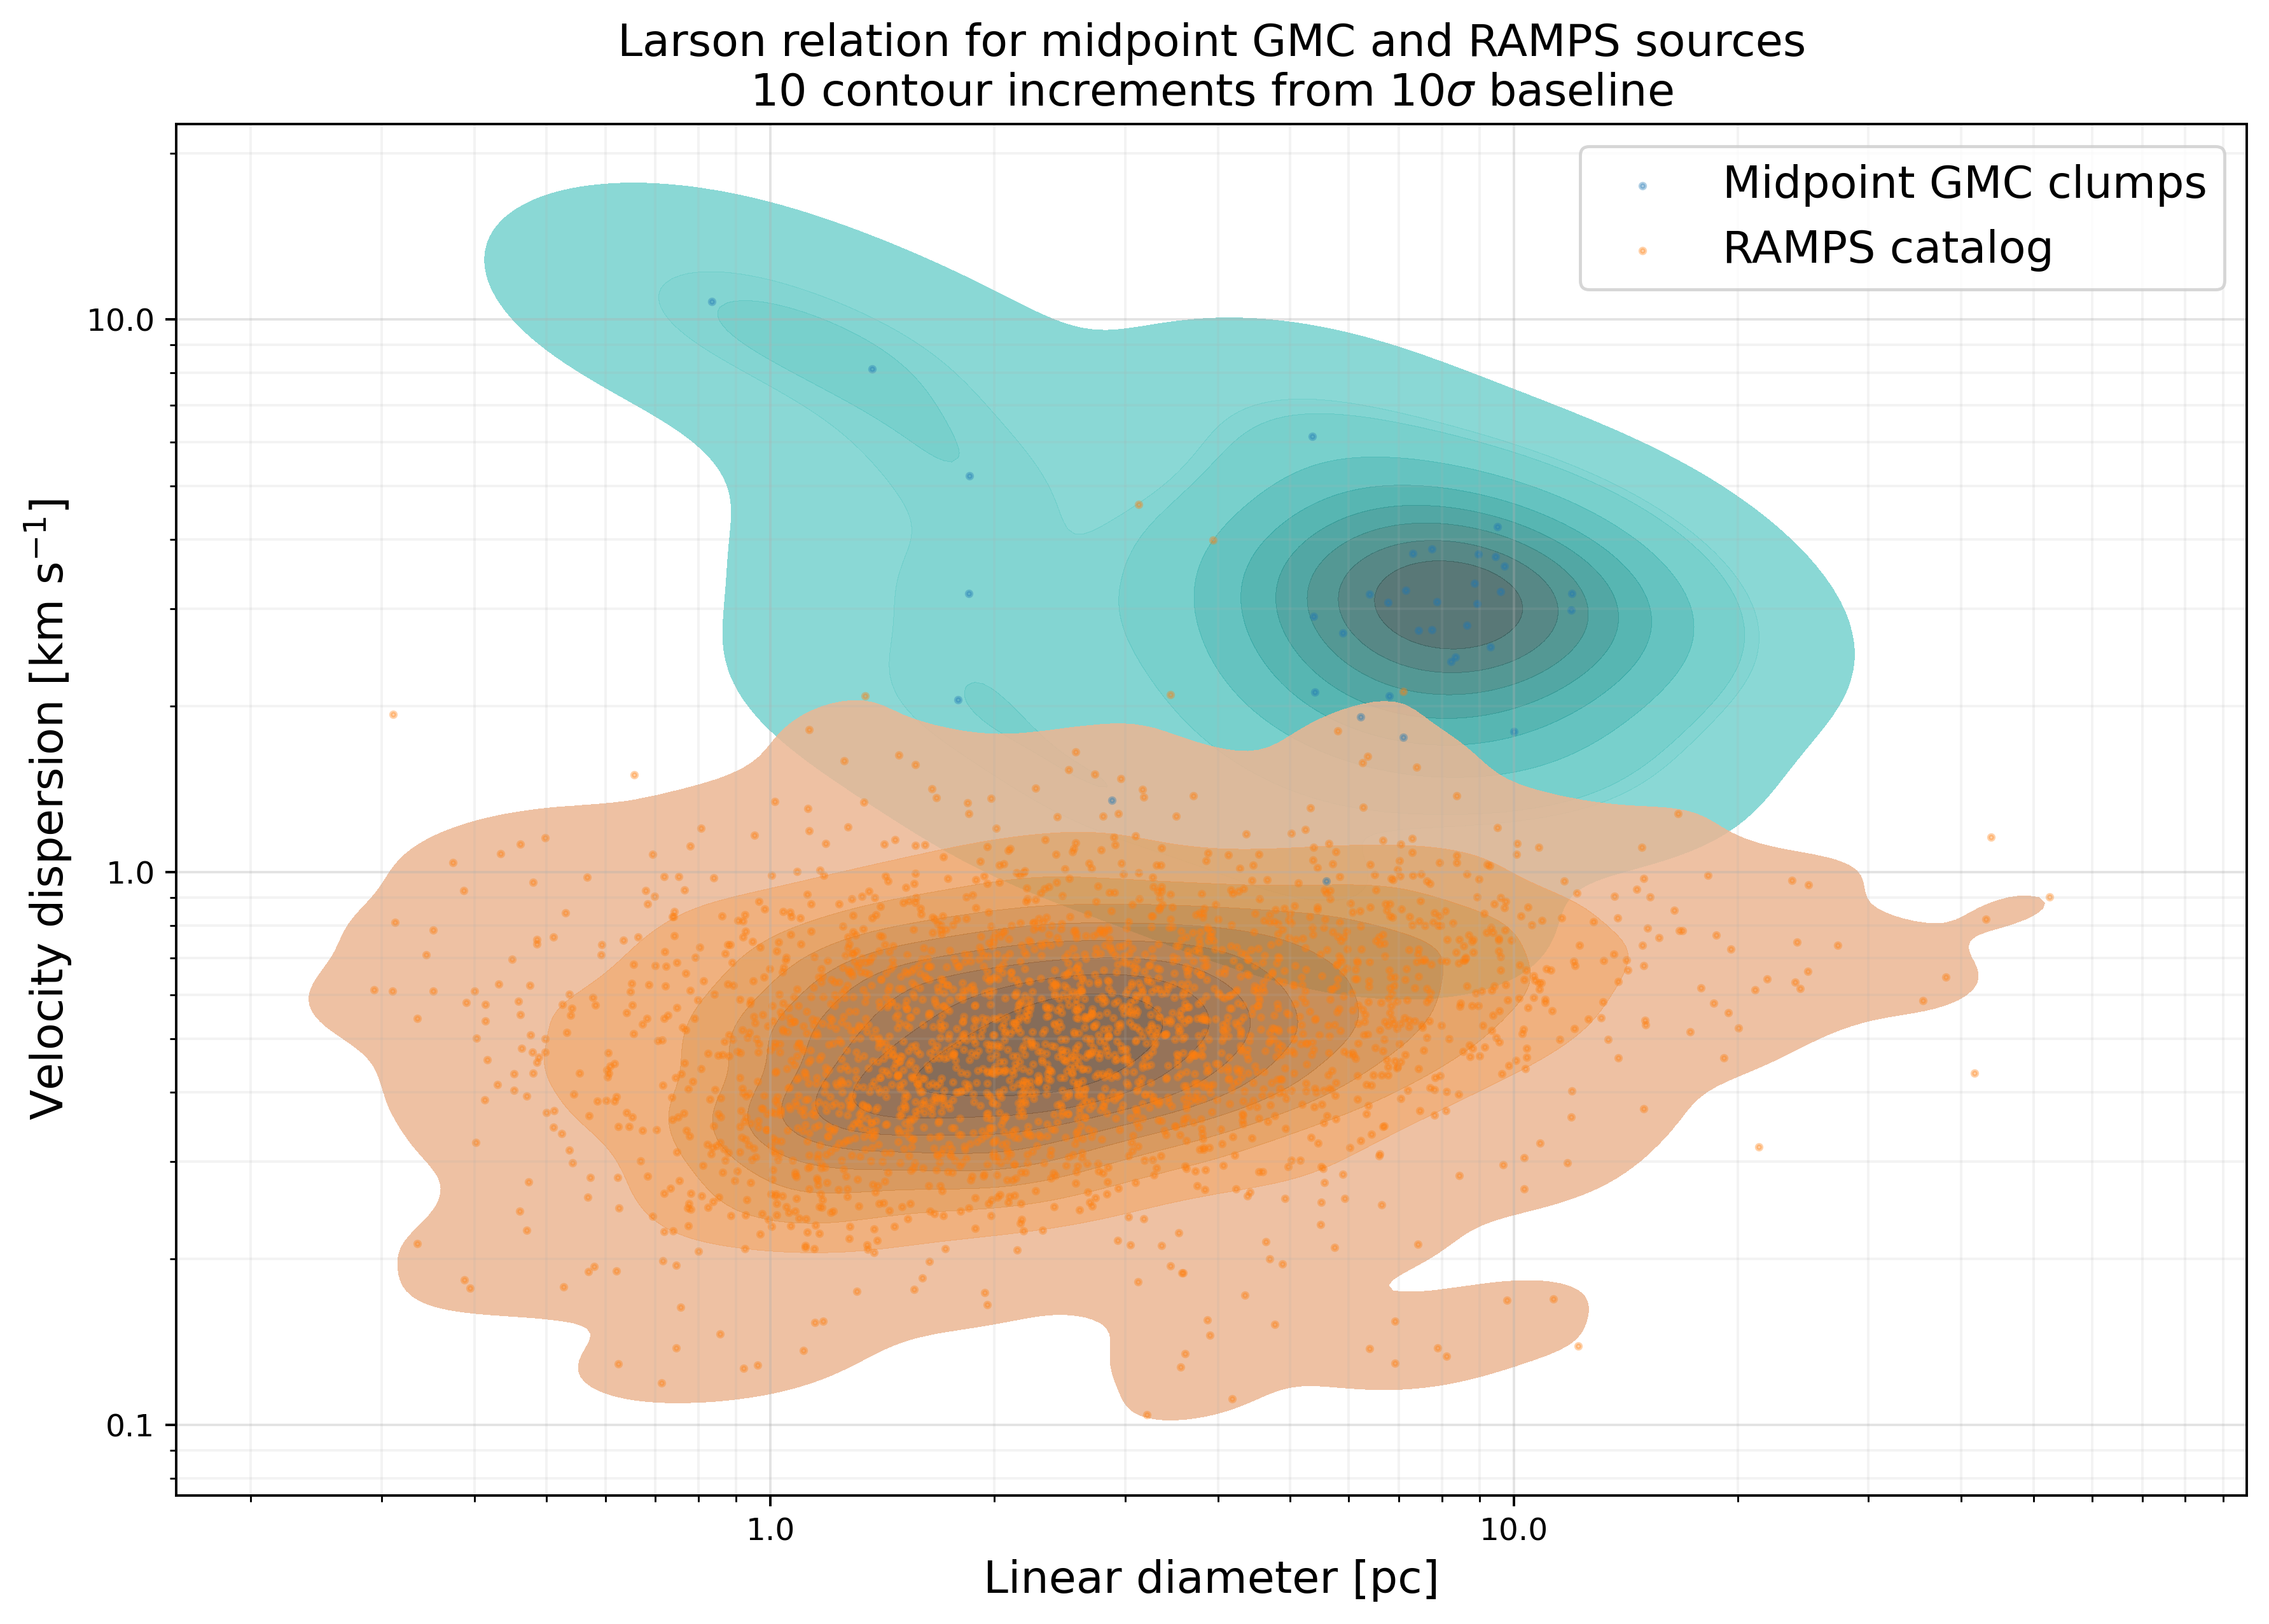

In [28]:
plt.figure(figsize= (12, 8), dpi= 350)

plt.loglog()

sns.kdeplot(x = pilot_table['Linear Size (pc)'], y = pilot_table['sigma (km/s)'], fill= True, thresh= 0.01, alpha= 0.85, color= 'mediumturquoise')
sns.kdeplot(x = ramps_table['Linear Size (pc)'], y = ramps_table['sigma (km/s)'], fill= True, thresh= 0.01, alpha= 0.85, color= 'sandybrown')

# pilotopt, pilotcov = curve_fit(expFunc, pilot_table['Linear Size (pc)'], pilot_table['sigma (km/s)'])
# rampsopt, rampscov = curve_fit(expFunc, ramps_table['Linear Size (pc)'], ramps_table['sigma (km/s)'])

# plt.plot([min(pilot_table['Linear Size (pc)']), max(pilot_table['Linear Size (pc)'])], [expFunc(min(pilot_table['Linear Size (pc)']), *pilotopt), expFunc(max(pilot_table['Linear Size (pc)']), *pilotopt)], label= '%.2f(x$^{%.4f}$)' % tuple(pilotopt))
# plt.plot([min(ramps_table['Linear Size (pc)']), max(ramps_table['Linear Size (pc)'])], [expFunc(min(ramps_table['Linear Size (pc)']), *rampsopt), expFunc(max(ramps_table['Linear Size (pc)']), *rampsopt)], label= '%.2f(x$^{%.4f}$)' % tuple(rampsopt))

plt.scatter(pilot_table['Linear Size (pc)'], pilot_table['sigma (km/s)'], label = 'Midpoint GMC clumps', color= 'tab:blue',alpha= 0.35, s= 3)
plt.scatter(ramps_table['Linear Size (pc)'], ramps_table['sigma (km/s)'], label = 'RAMPS catalog', color= 'tab:orange', alpha = 0.35, s=3)

# plt.scatter(5.5, 3, color = 'lightblue', label = 'Midpoint GMC clumps')
# plt.scatter(2.5, .5, color = 'orange', label = 'RAMPS catalog')

plt.title(f'Larson relation for midpoint GMC and RAMPS sources\n{params}', fontsize= 'x-large')
plt.legend(fontsize = 'x-large')
plt.xlabel('Linear diameter [pc]', fontsize = 'x-large')
plt.ylabel('Velocity dispersion [km s$^{-1}$]', fontsize = 'x-large')

ax = plt.gca()
for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(ScalarFormatter())

plt.grid(True, which= 'major', alpha= 0.35)
plt.grid(True, which= 'minor', alpha= 0.15)

plt.show()

In [25]:
# plt.figure(figsize= (12,8))
# plt.title('Size')
# plt.hist(pilot_table['Linear Size (pc)'], label= 'Pilot', alpha = 0.5, density = True, bins= 20)
# plt.hist(ramps_table['Linear Size (pc)'], label= 'RAMPS', alpha = 0.5, density = True, bins= 20)
# plt.legend()
# # plt.yscale('log')
# # ax = plt.gca()
# # for axis in [ax.xaxis, ax.yaxis]:
# #     axis.set_major_formatter(ScalarFormatter())
# plt.xlabel('Size')
# plt.ylabel('Amount')
# plt.show()

# plt.figure(figsize= (12,8))
# plt.title('SigV')
# plt.hist(pilot_table['sigma (km/s)'], label= 'Pilot', alpha = 0.5, density = True, bins= 20)
# plt.hist(ramps_table['sigma (km/s)'], label= 'RAMPS', alpha = 0.5, density = True, bins= 20)
# plt.legend()
# # plt.yscale('log')
# # ax = plt.gca()
# # for axis in [ax.xaxis, ax.yaxis]:
# #     axis.set_major_formatter(ScalarFormatter())
# plt.xlabel('Linewidth')
# plt.ylabel('Amount')
# plt.show()